# Используемые в проекте библиотеки

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Добавление датасета и работа с ним


In [ ]:
df = pd.read_csv("dota2_hero_stats.csv")

# Изначальная Очистка датасета

In [ ]:
#Преобразуем процентные строки в числа
for col in ['Win Rate', 'Pick Rate']:
  if df[col].dtype == object:
    df[col] = df[col].str.rstrip('%').astype(float)/100
  else:
    if df[col].max()>1:
      df[col] = df[col]/100


In [ ]:
#проверка типов
print('Типы после очистки:')
print(df.dtypes)
print('Уникальных патчей: ',sorted(df['Patch'].unique()))
print('Количество героев в каждом патче:')
print(df.groupby('Patch')['Hero'].nunique())

Типы после очистки:
Hero          object
Win Rate     float64
Pick Rate    float64
KDA Ratio    float64
Patch        float64
dtype: object
Уникальных патчей:  [np.float64(7.3), np.float64(7.31), np.float64(7.32), np.float64(7.33), np.float64(7.34), np.float64(7.35)]
Количество героев в каждом патче:
Patch
7.30    123
7.31    123
7.32    124
7.33    124
7.34    124
7.35    124
Name: Hero, dtype: int64


# Создание Функций для визуализации

In [ ]:
#2 Вспомогательные функции для визуализации
def plot_top10_horizontal(data, column, title, xlabel, color = 'stellblue'):
  '''Горизонтальная столбчатая диаграмма топ-10.'''
  top  = data.nlargest(10,column)
  fig, ax = plt.subplots(figsize=(10,6))
  ax.barh(top['Hero'], top[column]*100, color = color, edgecolor ='black')
  ax.invert_yaxis()
  ax.set_title(title)
  ax.set_xlabel(xlabel)
  for i, (val,hero) in enumerate(zip(top[column]*100, top['Hero'])):
    ax.text(val+0.5, i, f'{val:.1f}%', va='center', fontsize = 9)
  plt.tight_layout()
  plt.show()

def plot_scatter_imb(data, patch_str, top_imb = 5):
  '''
  Scatter plot винрейт vs пикрейт для одного патча с выделением top_imb героев
  с низким пикрейтом и высоким винрейтом. Возращает DataFrame с выделенными
  героями.
  '''
  #Определяем 'скрытых имб': низкий пикрейт(ниже медианы), высокий винрейт(выше медианы)
  med_pick = data['Pick Rate'].median()
  med_win = data['Win Rate'].median()
  imb = data[(data['Pick Rate'] < med_pick) & (data['Win Rate'] > med_win)]
  #Сортируем по винрейту и выбираем топ-5
  imb_top = imb.nlargest(top_imb, 'Win Rate')

  fig, ax = plt.subplots(figsize=(10,6))
  #Все оставшиеся герои
  ax.scatter(data['Pick Rate']*100, data['Win Rate']*100, alpha = 0.6, c = 'gray',
             label = 'Остальные')
  #Выделенные имбы
  ax.scatter(imb_top['Pick Rate']*100, imb_top['Win Rate']*100, color = 'red',
             s = 80, label = 'Скрытые имбы')
  for _, row in imb_top.iterrows():
    ax.annotate(row['Hero'], (row['Pick Rate']*100, row['Win Rate']*100),
                textcoords='offset points', xytext = (5,5), fontsize = 9,
                color = 'red')
    ax.set_title(f'Скрытые имбы патча {patch_str} (низкий пикрейт, высокий винрейт)')
    ax.set_xlabel('Pick Rate, %')
    ax.set_ylabel('Win Rate, %')
    ax.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return imb_top[['Hero', 'Win Rate', 'Pick Rate', 'KDA Ratio']]

# Задача №1



===== Патч 7.3 =====


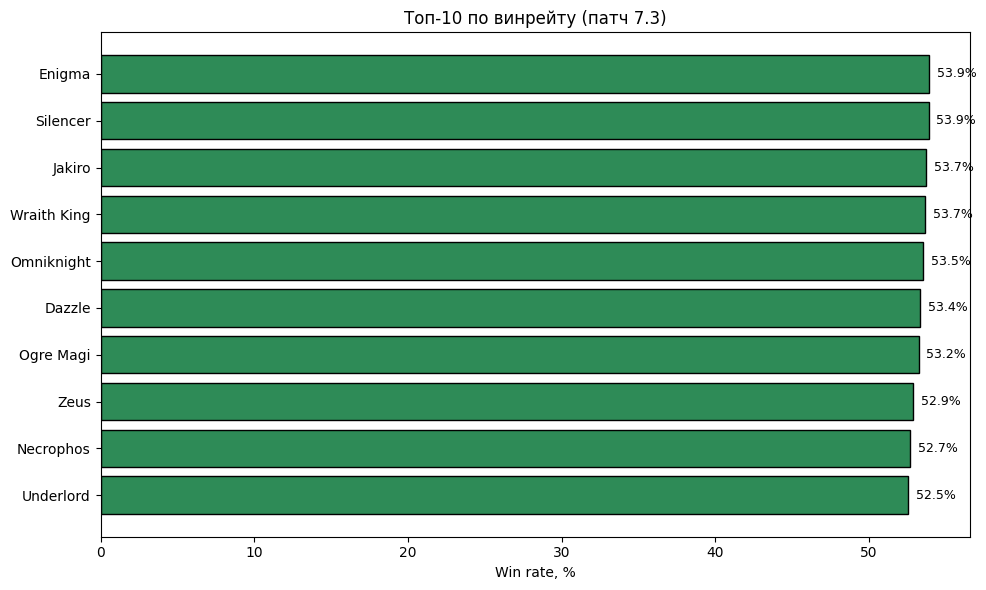


===== Патч 7.31 =====


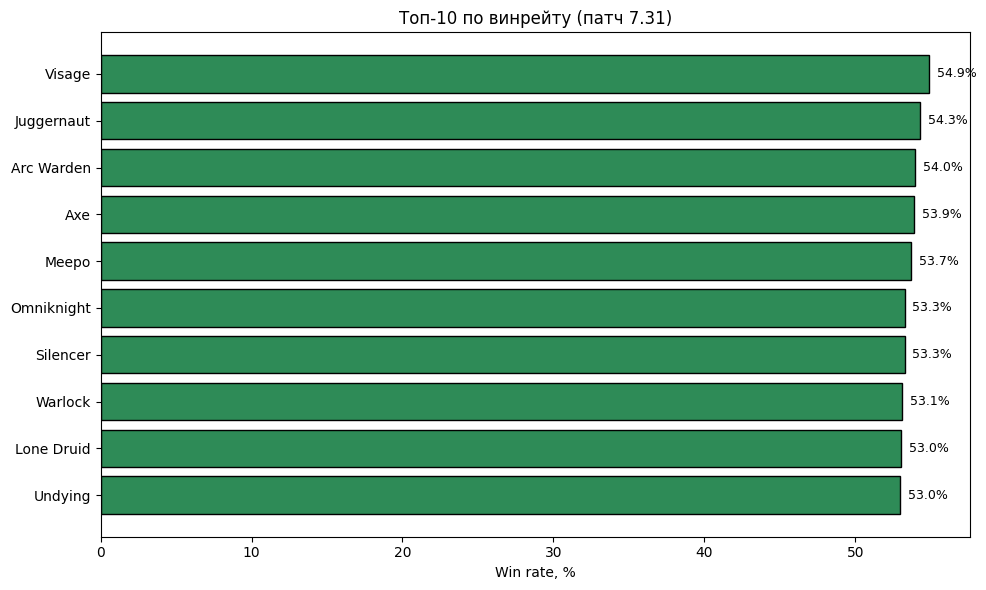


===== Патч 7.32 =====


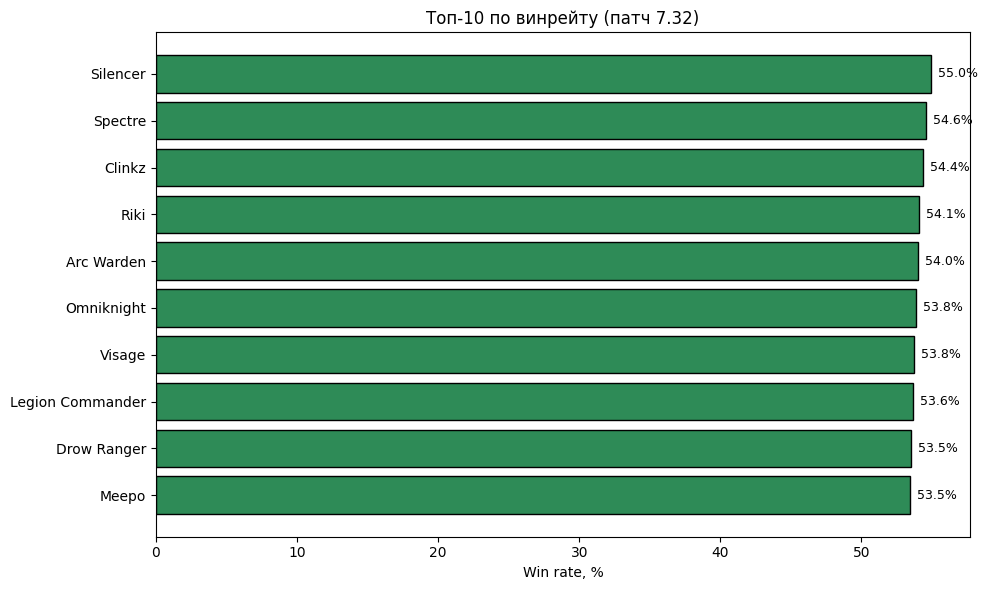


===== Патч 7.33 =====


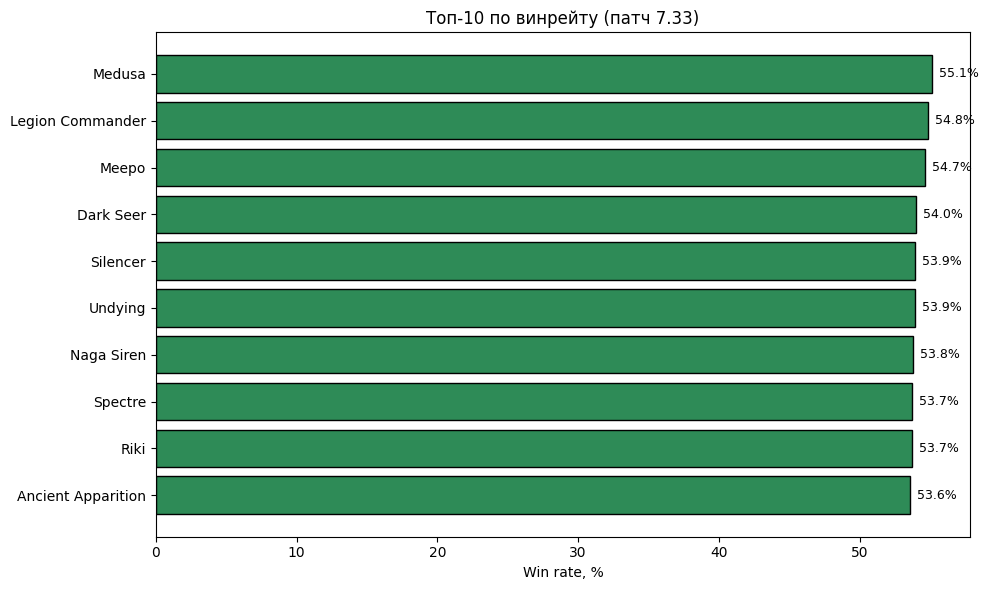


===== Патч 7.34 =====


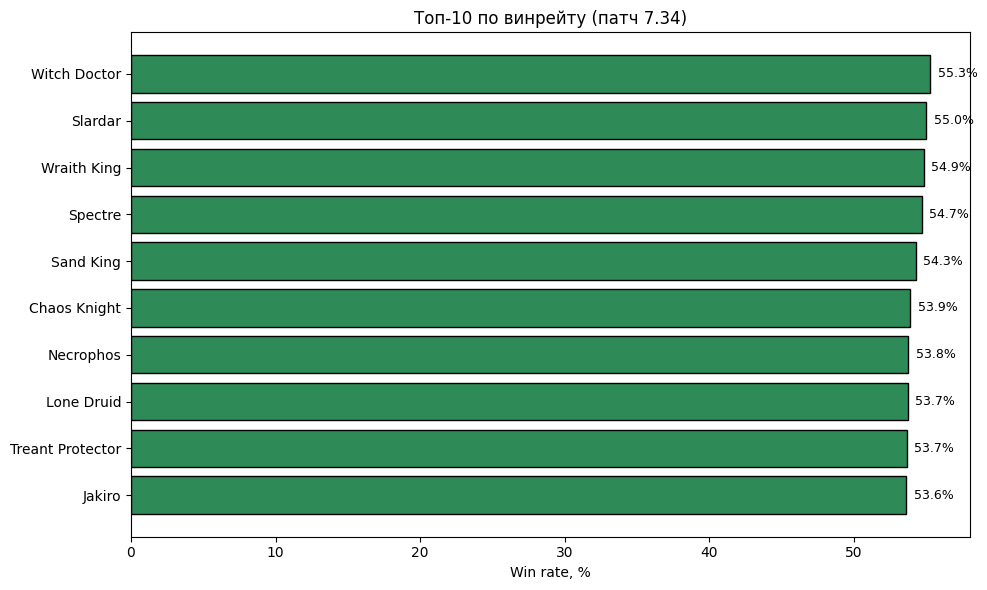


===== Патч 7.35 =====


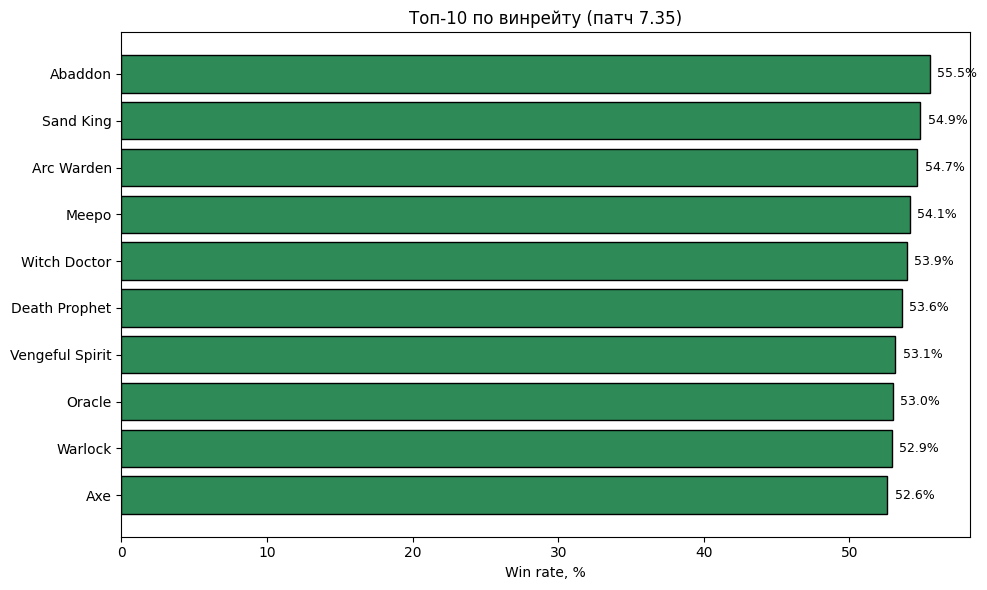

In [ ]:

#3. Задача 1а: Топ-10 героев по винрейту и пикрейту для каждого патча
patches = sorted(df['Patch'].unique())
for patch in patches:
  data_patch = df[df['Patch'] == patch]
  print(f'\n===== Патч {patch} =====')
  #Винрейт
  plot_top10_horizontal(data_patch, 'Win Rate', f'Топ-10 по винрейту (патч {patch})',
                        'Win rate, %', color = 'seagreen')


===== Скрытые имбы патча 7.3 =====


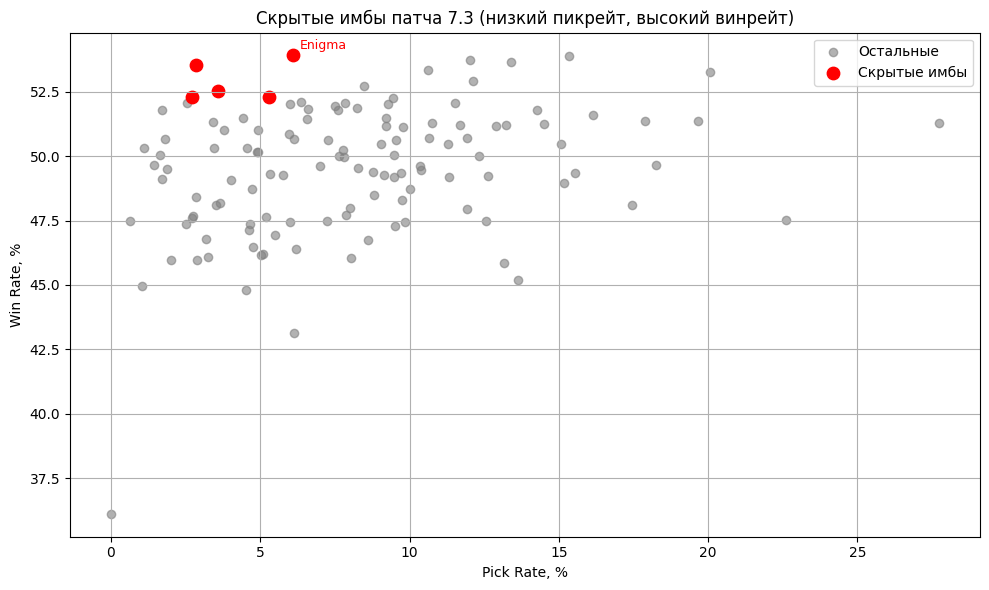

,Hero,Win Rate,Pick Rate,KDA Ratio
619,Enigma,0.5391,0.0610,2.54
623,Omniknight,0.5353,0.0286,2.33
628,Underlord,0.5255,0.0358,2.78
629,Centaur Warrunner,0.5229,0.0528,2.75
630,Naga Siren,0.5229,0.0271,3.35



===== Скрытые имбы патча 7.31 =====


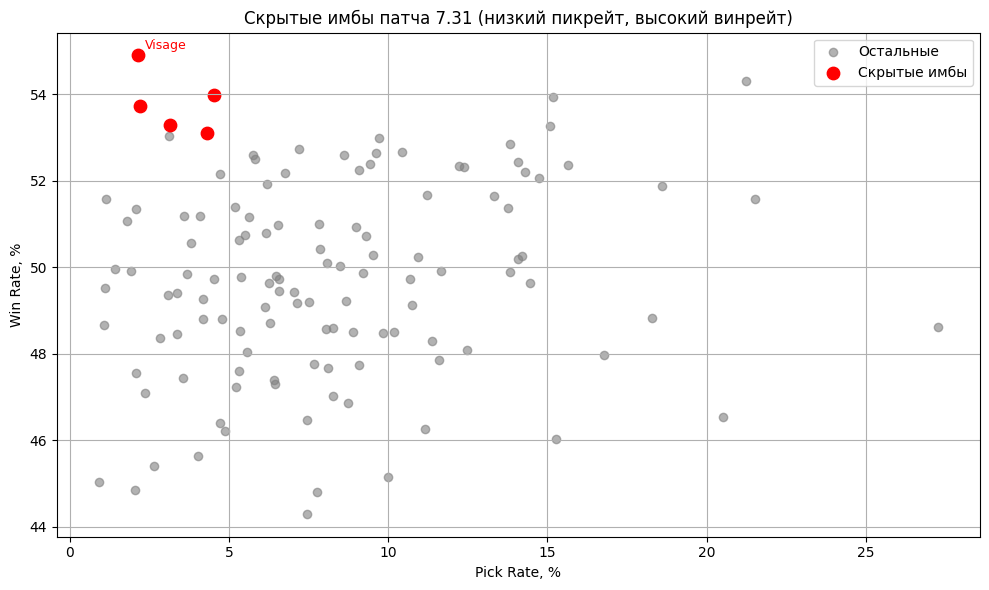

,Hero,Win Rate,Pick Rate,KDA Ratio
496,Visage,0.5489,0.0214,3.23
498,Arc Warden,0.5397,0.0452,3.36
500,Meepo,0.5372,0.0219,2.70
501,Omniknight,0.5329,0.0316,2.42
503,Warlock,0.5311,0.0432,2.79



===== Скрытые имбы патча 7.32 =====


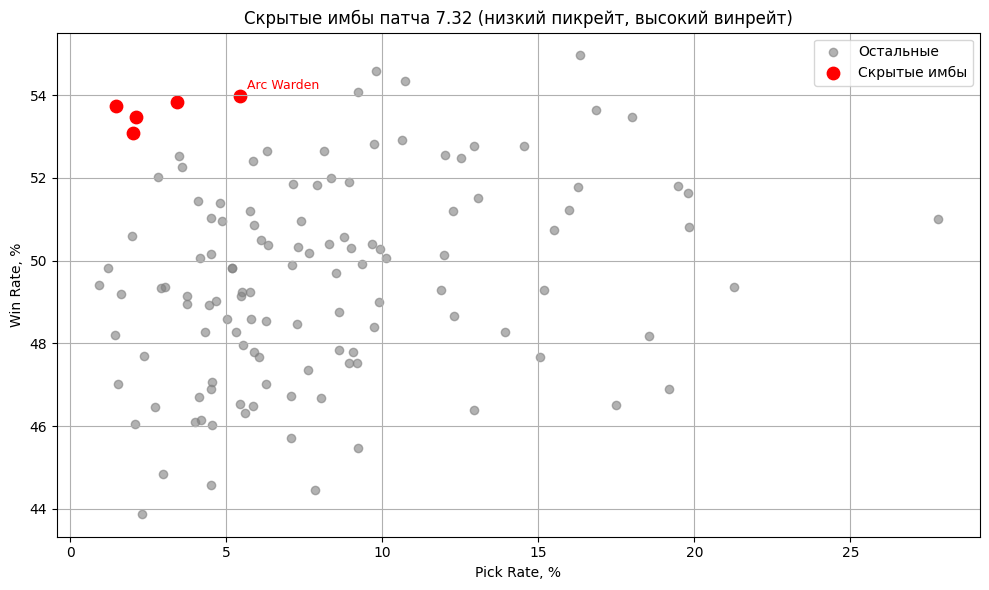

,Hero,Win Rate,Pick Rate,KDA Ratio
376,Arc Warden,0.5398,0.0544,3.46
377,Omniknight,0.5384,0.0343,2.43
378,Visage,0.5375,0.0147,3.13
381,Meepo,0.5347,0.0209,2.72
382,Lycan,0.5308,0.0200,3.35



===== Скрытые имбы патча 7.33 =====


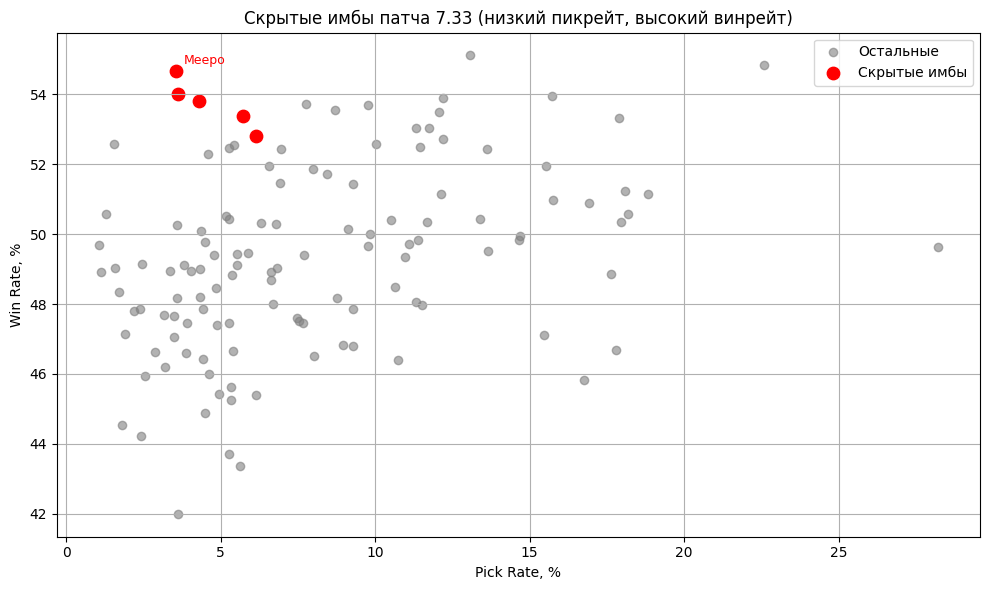

,Hero,Win Rate,Pick Rate,KDA Ratio
250,Meepo,0.5467,0.0357,3.03
251,Dark Seer,0.5400,0.0362,3.24
254,Naga Siren,0.5382,0.0429,3.77
259,Underlord,0.5337,0.0573,2.96
263,Oracle,0.5281,0.0616,2.96



===== Скрытые имбы патча 7.34 =====


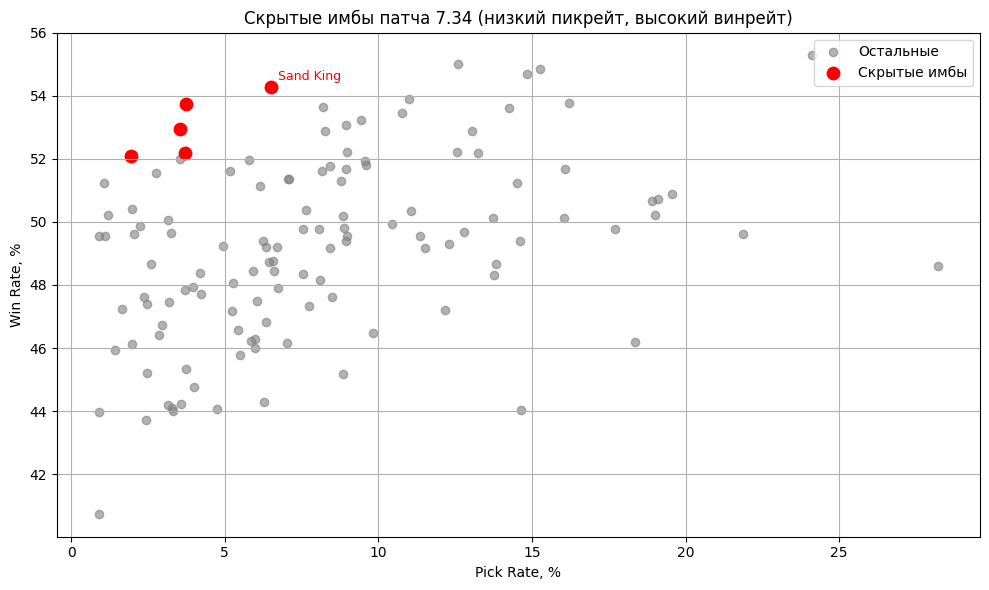

,Hero,Win Rate,Pick Rate,KDA Ratio
128,Sand King,0.5429,0.0652,2.72
131,Lone Druid,0.5373,0.0375,3.29
137,Arc Warden,0.5294,0.0353,3.37
143,Oracle,0.5218,0.0372,2.92
144,Meepo,0.5210,0.0194,2.80



===== Скрытые имбы патча 7.35 =====


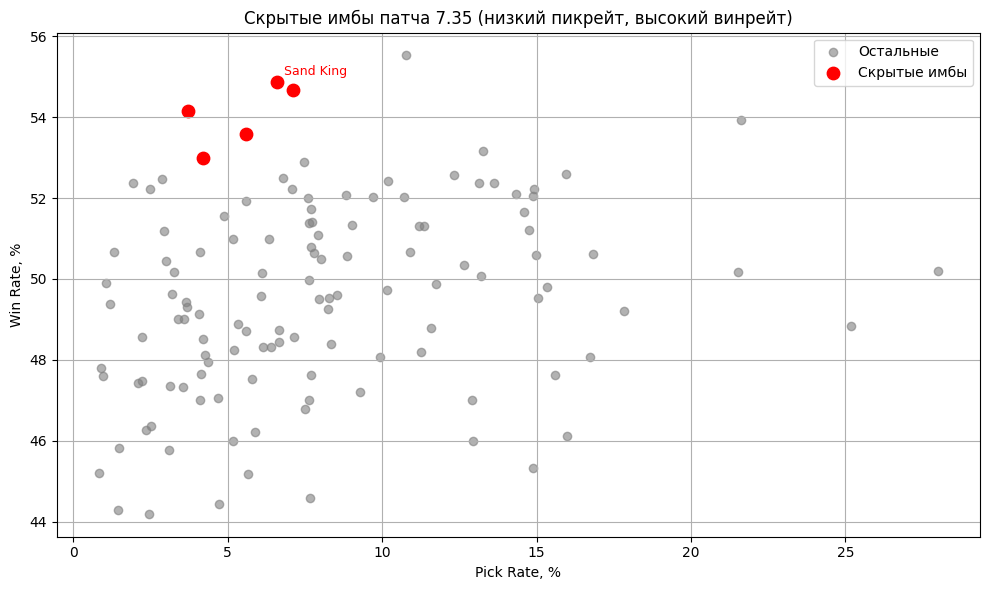

,Hero,Win Rate,Pick Rate,KDA Ratio
1,Sand King,0.5486,0.0660,2.82
2,Arc Warden,0.5466,0.0712,3.32
3,Meepo,0.5415,0.0372,2.96
5,Death Prophet,0.5359,0.0560,3.45
7,Oracle,0.5300,0.0419,3.14


In [ ]:
#4. Задача 1б: 5 скрытых имб для каждого патча
for patch in patches:
  data_patch = df[df['Patch'] == patch]
  print(f'\n===== Скрытые имбы патча {patch} =====')
  imb_table = plot_scatter_imb(data_patch, patch, top_imb = 5)
  display(imb_table)

# Задача №2

In [ ]:
#5. Задача 2: Прогноз винрейта на следующий патч для 10 героев

#Выбираем 10 героев, которые присутствуют во всех патчах(или в большинстве)
hero_counts = df.groupby('Hero')['Patch'].nunique()
heroes_all_patches = hero_counts[hero_counts == len(patches)].index
#Возьмем первые 10 героев
selected_heroes = sorted(heroes_all_patches)[:10]
print(f'Выбранные герои для прогноза: {selected_heroes}')

Выбранные герои для прогноза: ['Abaddon', 'Alchemist', 'Ancient Apparition', 'Anti-Mage', 'Arc Warden', 'Axe', 'Bane', 'Batrider', 'Beastmaster', 'Bloodseeker']


In [ ]:
#Подготовим данные для прогноза: переведем патчи в числа(0,1,2,3....)
patch_mapping = {p: i for i, p in enumerate(patches)}
df['Patch_idx'] = df['Patch'].map(patch_mapping)

#Следующий патч
next_idx = len(patches)
next_patch_name = '7.36'


In [1]:

#Функция для прогноза одного героя с построением графика
def forecast_hero(hero_name):
  hero_data = df[df['Hero'] == hero_name].sort_values('Patch_idx')
  X = hero_data['Patch_idx'].values.reshape(-1,1)
  Y = hero_data['Win Rate'].values

  #Линейная регрессия
  model = LinearRegression()
  model.fit(X, Y)
  pred = model.predict([[next_idx]])[0]

  #Визуализация
  fig, ax = plt.subplots(figsize = (8,4))
  ax.plot(hero_data['Patch'], Y*100, marker='o', label='Исторический винрейт',
          color='steelblue')
  ax.axvline(x=patches[-1], color='gray', linestyle='--', alpha=0.5)
  ax.scatter(next_patch_name, pred*100, color='red', s=100, zorder=5,
             label=f'Прогноз {next_patch_name}')
  ax.annotate(f'{pred*100:.1f}%', (next_patch_name, pred*100),
              textcoords="offset points",
              xytext=(10,0), fontsize=11, color='red')
  ax.set_title(f'Прогноз винрейта {hero_name}')
  ax.set_ylabel('Win Rate, %')
  ax.legend()
  plt.grid(True)
  plt.tight_layout()
  plt.show()
  return pred




===== Прогноз винрейта на патч 7.36 =====


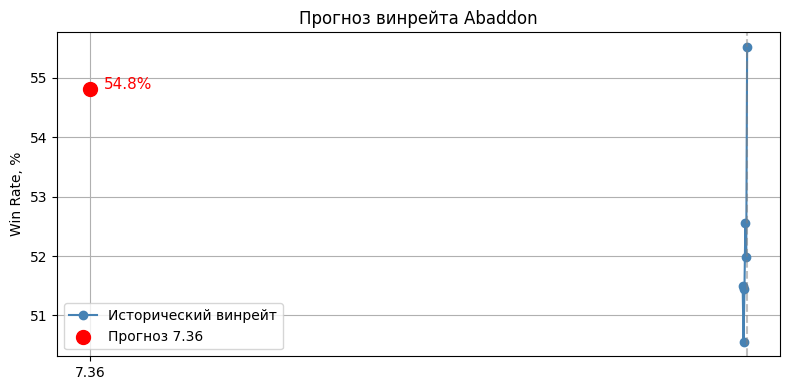

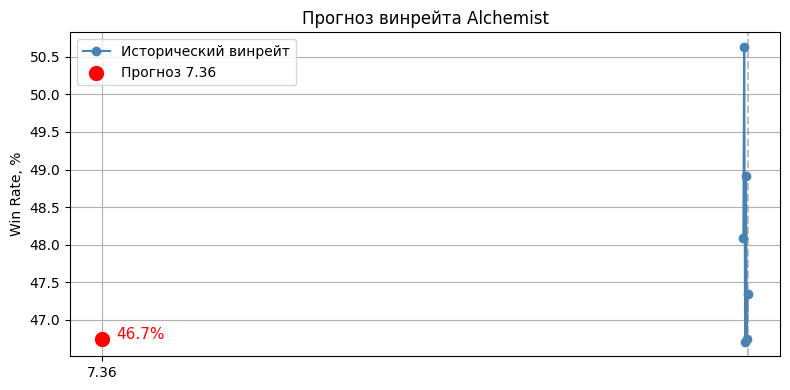

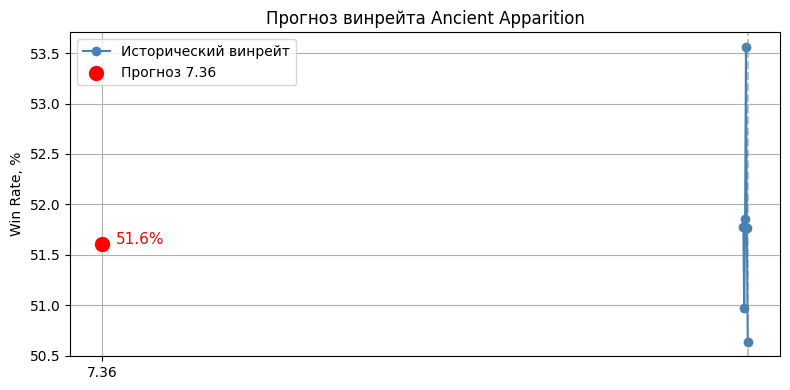

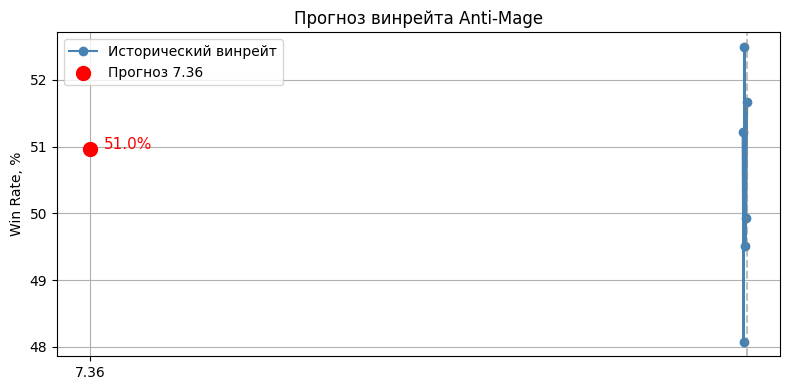

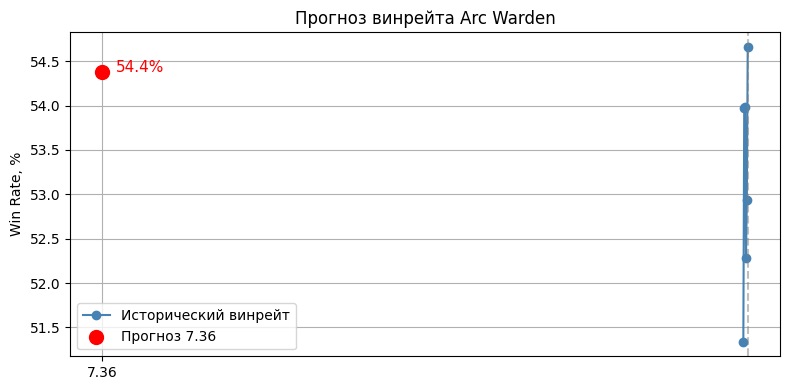

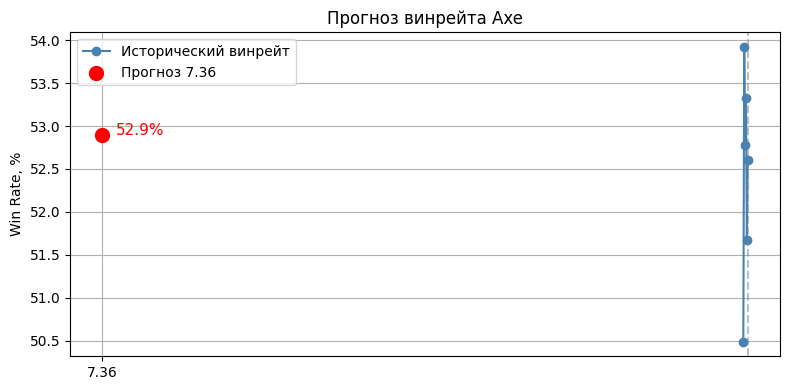

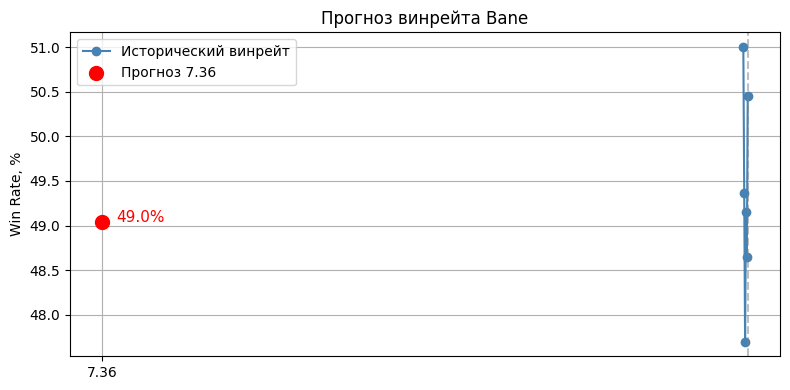

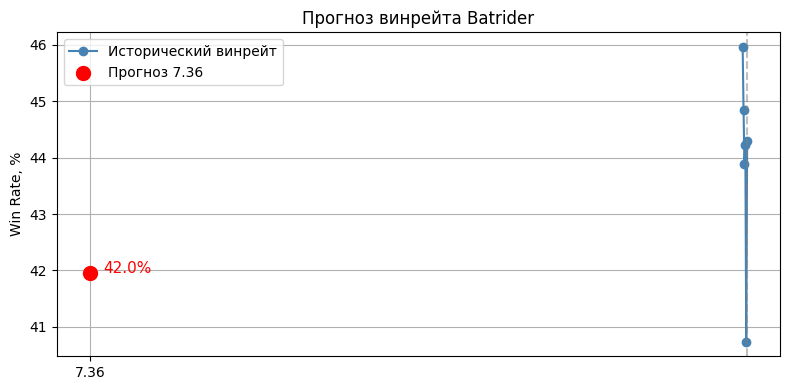

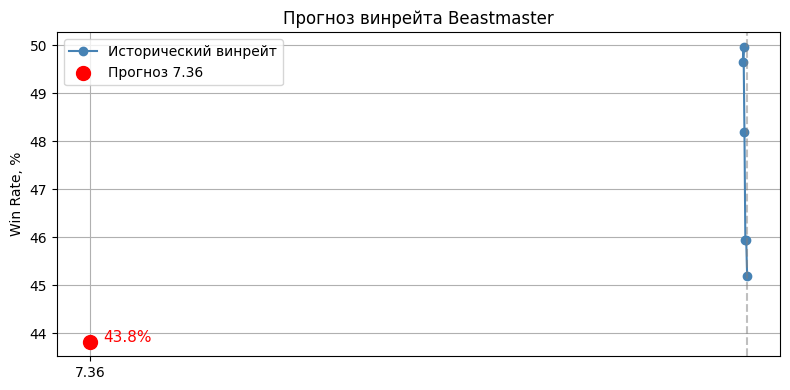

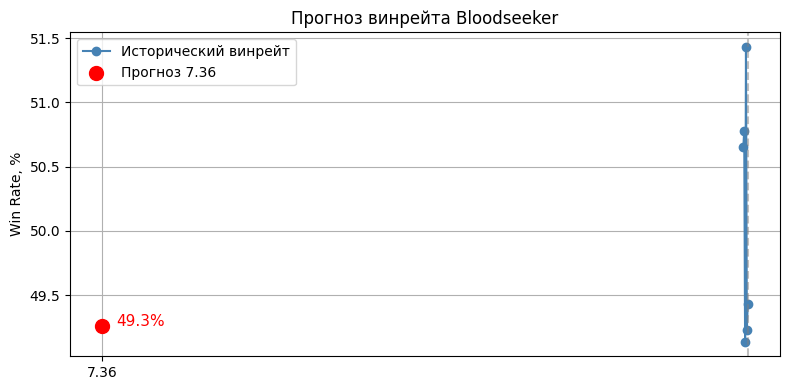

,Hero,Predicted Win Rate
0,Abaddon,54.8%
1,Alchemist,46.7%
2,Ancient Apparition,51.6%
3,Anti-Mage,51.0%
4,Arc Warden,54.4%
5,Axe,52.9%
6,Bane,49.0%
7,Batrider,42.0%
8,Beastmaster,43.8%
9,Bloodseeker,49.3%


In [ ]:
#Прогнозируем для всех 10 героев и выводим таблицу
predictions = {}
print('\n===== Прогноз винрейта на патч 7.36 =====')
for hero in selected_heroes:
  pred = forecast_hero(hero)
  predictions[hero] = pred
#Итоговая таблица прогнозов
pred_df = pd.DataFrame({
    'Hero': list(predictions.keys()),
    'Predicted Win Rate': [f'{v*100:.1f}%' for v in predictions.values()]
})
display(pred_df)